# Module 3.2 — EDA: nhóm hàng, cửa hàng, thời gian, độ phủ (mục III / V)

**Đầu vào:** `outputs/daily_store_category.csv` — bảng mô hình từ notebook tiền xử lý.
**Đầu ra (thư mục `outputs/`):** `by_category.csv`, `by_store.csv`, `by_day.csv`, `by_weekday.csv`, `coverage.csv`, `so_luong_theo_ngay.png`, `so_luong_theo_nhom_hang.png`.

**Thứ tự chạy:** `Module3_1_tien_xu_ly` → `Module3_2_eda` → `Module3_3_random_forest`. Notebook 2 và 3 đọc `outputs/daily_store_category.csv`; nếu chưa có thì tự dựng lại từ file gốc.

**Cấu hình** (`.env`, mẫu ở `.env.example`): `DATA_FILE`, `DRIVE_ID`, `OUT_DIR`, `KHU_VUC`. Nếu chưa có file dữ liệu, module tự tải từ Google Drive theo `DRIVE_ID`.

**Chạy trên Google Colab:** upload `module3_preprocess.py` và `.env` lên cùng thư mục với notebook, rồi Runtime → Run all.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from module3_preprocess import OUT_DIR as OUT, TET, doc_bang_ngay, tai_ve

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
daily = doc_bang_ngay()
print(f"Bảng mô hình: {len(daily):,} dòng | {daily['Ngày'].min():%d/%m/%Y} → {daily['Ngày'].max():%d/%m/%Y}")

## 1. Theo nhóm hàng và cửa hàng

In [ ]:
TONG, TONG_TIEN = daily["so_luong"].sum(), daily["doanh_thu"].sum()
by_cat = (daily.groupby("Nhóm hàng").agg(so_luong=("so_luong", "sum"), doanh_thu=("doanh_thu", "sum"),
                                         so_cua_hang=("Mã cửa hàng", "nunique"), ty_le_o_co_ban=("co_giao_dich", "mean"),
                                         sl_tb_ngay=("so_luong", "mean"), sl_phuong_sai=("so_luong", "var"))
          .sort_values("so_luong", ascending=False))
by_cat["%_so_luong"] = by_cat["so_luong"] / TONG
by_cat["%_doanh_thu"] = by_cat["doanh_thu"] / TONG_TIEN
by_cat["%_luy_ke_SL"] = by_cat["%_so_luong"].cumsum()
by_cat.to_csv(f"{OUT}/by_category.csv", encoding="utf-8-sig"); display(by_cat)

ngay_co_ban = daily[daily["co_giao_dich"] == 1].groupby("Mã cửa hàng")["Ngày"].nunique().rename("ngay_co_ban")
by_store = (daily.groupby(["Mã cửa hàng", "Khu vực", "Vùng"], as_index=False)
            .agg(so_luong=("so_luong", "sum"), doanh_thu=("doanh_thu", "sum"), so_nhom_hang=("Nhóm hàng", "nunique"))
            .merge(ngay_co_ban, on="Mã cửa hàng").sort_values("so_luong", ascending=False).reset_index(drop=True))
by_store["%_so_luong"] = by_store["so_luong"] / TONG
by_store["%_luy_ke_SL"] = by_store["%_so_luong"].cumsum()
by_store.to_csv(f"{OUT}/by_store.csv", index=False, encoding="utf-8-sig")
display(by_store.head(10)); display(by_store.tail(10))

## 2. Theo thời gian (ngày, thứ trong tuần, Tết)

,so_luong,doanh_thu
Thứ,,
T2,"2,408.23","9,707,968,499.92"
T3,"2,113.25","8,365,117,950.58"
T4,"2,167.77","9,262,642,385.77"
T5,"2,259.69","9,495,965,803.38"
T6,"2,572.85","11,019,840,821.69"
T7,"2,735.77","11,509,084,788.38"
CN,"2,565.92","10,740,561,102.69"


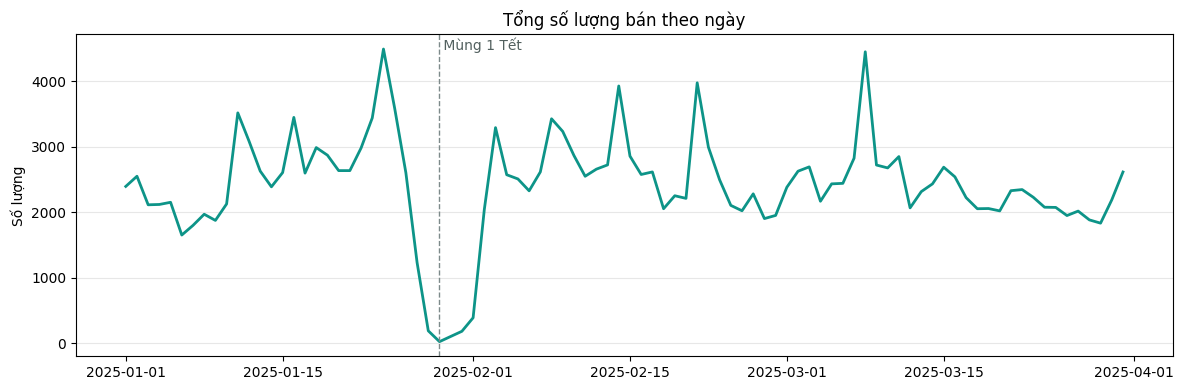

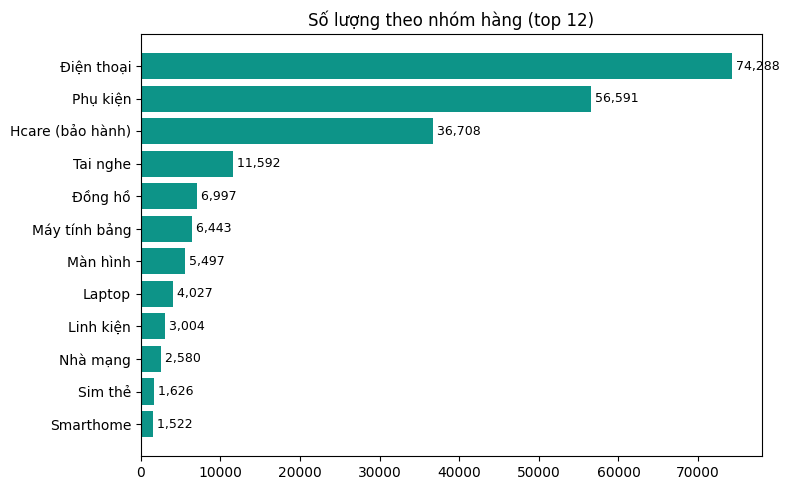

In [ ]:
THU = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
by_day = daily.groupby("Ngày")[["so_luong", "doanh_thu"]].sum().reset_index()
by_day["Thứ"] = by_day["Ngày"].dt.dayofweek.map(dict(enumerate(THU)))
by_day.to_csv(f"{OUT}/by_day.csv", index=False, encoding="utf-8-sig")
by_wd = by_day.groupby("Thứ")[["so_luong", "doanh_thu"]].mean().reindex(THU)
by_wd.to_csv(f"{OUT}/by_weekday.csv", encoding="utf-8-sig"); display(by_wd)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(by_day["Ngày"], by_day["so_luong"], color="#0d9488", lw=2)
ax.axvline(TET, color="#7d8a8a", ls="--", lw=1); ax.text(TET, ax.get_ylim()[1] * 0.95, " Mùng 1 Tết", color="#52605f")
ax.set_title("Tổng số lượng bán theo ngày"); ax.set_ylabel("Số lượng"); ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(f"{OUT}/so_luong_theo_ngay.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
top = by_cat["so_luong"].head(12)[::-1]
ax.barh(top.index, top.values, color="#0d9488"); ax.set_title("Số lượng theo nhóm hàng (top 12)")
for i, v in enumerate(top.values): ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
fig.tight_layout(); fig.savefig(f"{OUT}/so_luong_theo_nhom_hang.png", dpi=150); plt.show()

## 3. Độ phủ và đặc điểm biến mục tiêu

In [ ]:
# Độ phủ & đặc điểm biến mục tiêu — quyết định chọn mô hình (nhiều số 0 → Poisson/Tweedie; phương sai > trung bình → quá phân tán)
y = daily["so_luong"]
coverage = pd.DataFrame([
    ("Số ô cửa hàng × nhóm hàng × ngày", len(daily)),
    ("Tỷ lệ ô có giao dịch", daily["co_giao_dich"].mean()),
    ("Tỷ lệ ô số lượng = 0", y.eq(0).mean()),
    ("Số lượng TB / ô", y.mean()),
    ("Phương sai số lượng / ô", y.var()),
    ("Tỷ số phương sai / trung bình", y.var() / y.mean()),
    ("Trung vị số lượng / ô", y.median()),
    ("P95 số lượng / ô", y.quantile(.95)),
    ("Max số lượng / ô", y.max()),
], columns=["Chỉ tiêu", "Giá trị"])
coverage.to_csv(f"{OUT}/coverage.csv", index=False, encoding="utf-8-sig"); display(coverage)

,Chỉ tiêu,Giá trị
0,Số ô cửa hàng × nhóm hàng × ngày,"194,940.00"
1,Tỷ lệ ô có giao dịch,0.29
2,Tỷ lệ ô số lượng = 0,0.71
3,Số lượng TB / ô,1.11
4,Phương sai số lượng / ô,50.53
5,Tỷ số phương sai / trung bình,45.48
6,Trung vị số lượng / ô,0.00
7,P95 số lượng / ô,5.00
8,Max số lượng / ô,"1,274.00"


## 4. Tải kết quả về (Colab)

In [ ]:
tai_ve(OUT, "module3_eda_outputs")